In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!apt-get install -y fonts-nanum > /dev/null 2>&1

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

print(" 한글 폰트(나눔고딕) 설정 완료!")

# Google Colab 파일 업로드
from google.colab import files
uploaded = files.upload()

✅ 한글 폰트(나눔고딕) 설정 완료!


Saving 01_공정최적화_생산성향상.xlsx to 01_공정최적화_생산성향상.xlsx


In [ ]:
import os
import pandas as pd

target_files = [f for f in os.listdir('.') if f.endswith('.xlsx') and '01' in f]

if not target_files:
    raise FileNotFoundError("❌ 파일을 찾을 수 없습니다. 왼쪽 [파일] 탭에 엑셀 파일이 있는지 확인해주세요.")

filename = target_files[0]
print(f"🔍 찾은 파일명: {filename}")

# pd.read_excel() : 엑셀 파일을 DataFrame으로 읽기
raw = pd.read_excel(filename, sheet_name='용선품질_Si-S_예측', header=None)

# raw.iloc[2] : 인덱스 2번 행(=3번째 줄) → 컬럼명 행
cols = raw.iloc[2].tolist()

# raw.iloc[3:] : 4번째 줄부터 끝까지 = 실제 데이터
df = raw.iloc[3:].reset_index(drop=True)
df.columns = cols

df.columns

# 수치형 컬럼 변환
num_cols = ['노정압력_상부(kPa)', '노정압력_하부(kPa)', '풍구온도(℃)',
       '풍량(Nm3/min)', '장입코크스비(kg/t-pig)', '장입광석비(t/t-pig)', '고로내부온도_중단(℃)',
       '용선온도(℃)', '슬래그염기도(CaO-SiO2)', '출선량(t/h)', 'Si 실측(%)', 'S 실측(%)']

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"✅ 데이터 로드 완료! ({df.shape[0]}행 × {df.shape[1]}컬럼)")
df.head()

🔍 찾은 파일명: 01_공정최적화_생산성향상.xlsx
✅ 데이터 로드 완료! (2880행 × 15컬럼)


,측정일시,Heat_No,고로번호,노정압력_상부(kPa),노정압력_하부(kPa),풍구온도(℃),풍량(Nm3/min),장입코크스비(kg/t-pig),장입광석비(t/t-pig),고로내부온도_중단(℃),용선온도(℃),슬래그염기도(CaO-SiO2),출선량(t/h),Si 실측(%),S 실측(%)
0,2024-01-01 00:00,H24001,1,232.2,245.5,1153,6023,320.2,1.750,1448,1483,1.214,165.1,0.368,0.0223
1,2024-01-01 00:15,H24001,1,249.8,265.7,1176,5994,287.2,1.717,1489,1502,1.239,161.3,0.439,0.0198
2,2024-01-01 00:30,H24001,1,231.2,247.0,1162,5946,292.7,1.744,1522,1503,1.245,141.7,0.452,0.0140
3,2024-01-01 00:45,H24001,1,237.4,253.6,1196,5900,304.5,1.716,1439,1499,1.161,142.1,0.496,0.0261
4,2024-01-01 01:00,H24001,1,241.9,252.4,1150,5510,301.7,1.715,1440,1494,1.185,127.4,0.469,0.0243


In [ ]:
df.describe()

,노정압력_상부(kPa),노정압력_하부(kPa),풍구온도(℃),풍량(Nm3/min),장입코크스비(kg/t-pig),장입광석비(t/t-pig),고로내부온도_중단(℃),용선온도(℃),슬래그염기도(CaO-SiO2),출선량(t/h),Si 실측(%),S 실측(%)
count,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000,2880.000000
mean,230.055486,245.040347,1150.212847,5799.222569,310.056319,1.720922,1479.716667,1489.870486,1.180738,145.178438,0.449482,0.024901
std,8.109319,8.352788,29.500558,119.756762,11.902959,0.040288,24.864389,14.943621,0.040187,18.047845,0.046928,0.004374
min,201.100000,218.700000,1040.000000,5301.000000,270.500000,1.591000,1398.000000,1437.000000,1.045000,70.900000,0.272000,0.009900
25%,224.400000,239.200000,1131.000000,5721.000000,302.100000,1.695000,1463.000000,1480.000000,1.153000,133.075000,0.418000,0.021900
50%,230.100000,245.200000,1150.000000,5797.500000,310.000000,1.720000,1480.000000,1490.000000,1.180000,145.100000,0.450000,0.024800
75%,235.800000,250.900000,1169.250000,5879.000000,317.700000,1.748000,1496.000000,1500.000000,1.207000,157.000000,0.481000,0.027900
max,256.200000,272.500000,1251.000000,6231.000000,352.400000,1.888000,1568.000000,1541.000000,1.316000,210.400000,0.621000,0.041500


In [ ]:
# 결측값(NaN) 확인
missing = df.isnull().sum()
print("📋 결측값 현황:")
if missing[missing > 0].empty:
    print("  ✅ 결측값 없음! 바로 모델링 가능합니다.")
else:
    print(missing[missing > 0])
    print("\n💡 결측값 처리 방법: 삭제(dropna) or 대체(fillna) 검토 필요")

# 추가: 각 컬럼의 데이터 타입 확인
print("\n📋 컬럼별 데이터 타입:")
print(df.dtypes)

📋 결측값 현황:
  ✅ 결측값 없음! 바로 모델링 가능합니다.

📋 컬럼별 데이터 타입:
측정일시                 object
Heat_No              object
고로번호                 object
노정압력_상부(kPa)        float64
노정압력_하부(kPa)        float64
풍구온도(℃)               int64
풍량(Nm3/min)           int64
장입코크스비(kg/t-pig)    float64
장입광석비(t/t-pig)      float64
고로내부온도_중단(℃)          int64
용선온도(℃)               int64
슬래그염기도(CaO-SiO2)    float64
출선량(t/h)            float64
Si 실측(%)            float64
S 실측(%)             float64
dtype: object


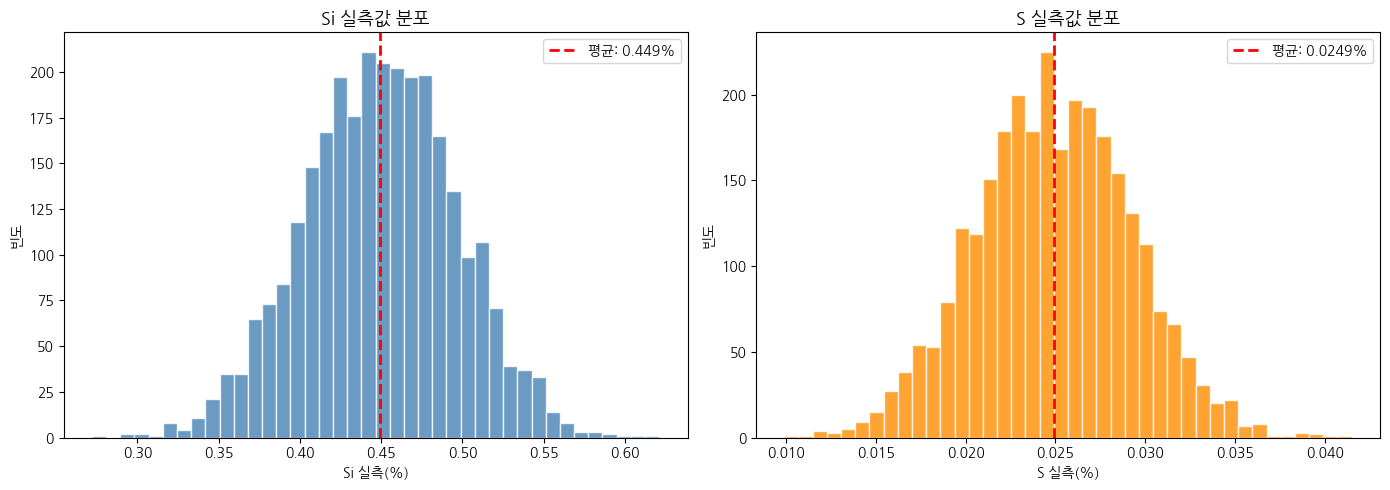


💡 분석:
  · Si 평균: 0.449, 표준편차: 0.047
  · S 평균: 0.0249, 표준편차: 0.0044


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Si 실측값 분포 
axes[0].hist(df['Si 실측(%)'].dropna(), bins=40,
             color='steelblue', edgecolor='white', alpha=0.8)

axes[0].axvline(df['Si 실측(%)'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f"평균: {df['Si 실측(%)'].mean():.3f}%")

axes[0].set_title('Si 실측값 분포', fontsize=13)
axes[0].set_xlabel('Si 실측(%)')
axes[0].set_ylabel('빈도')
axes[0].legend()

# 오른쪽: S 실측값 분포
axes[1].hist(df['S 실측(%)'].dropna(), bins=40,
             color='darkorange', edgecolor='white', alpha=0.8)

axes[1].axvline(df['S 실측(%)'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f"평균: {df['S 실측(%)'].mean():.4f}%")

axes[1].set_title('S 실측값 분포', fontsize=13)
axes[1].set_xlabel('S 실측(%)')
axes[1].set_ylabel('빈도')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 분석:")
print(f"  · Si 평균: {df['Si 실측(%)'].mean():.3f}, 표준편차: {df['Si 실측(%)'].std():.3f}")
print(f"  · S 평균: {df['S 실측(%)'].mean():.4f}, 표준편차: {df['S 실측(%)'].std():.4f}")

In [ ]:
df.columns

Index(['측정일시', 'Heat_No', '고로번호', '노정압력_상부(kPa)', '노정압력_하부(kPa)', '풍구온도(℃)',
       '풍량(Nm3/min)', '장입코크스비(kg/t-pig)', '장입광석비(t/t-pig)', '고로내부온도_중단(℃)',
       '용선온도(℃)', '슬래그염기도(CaO-SiO2)', '출선량(t/h)', 'Si 실측(%)', 'S 실측(%)'],
      dtype='object')

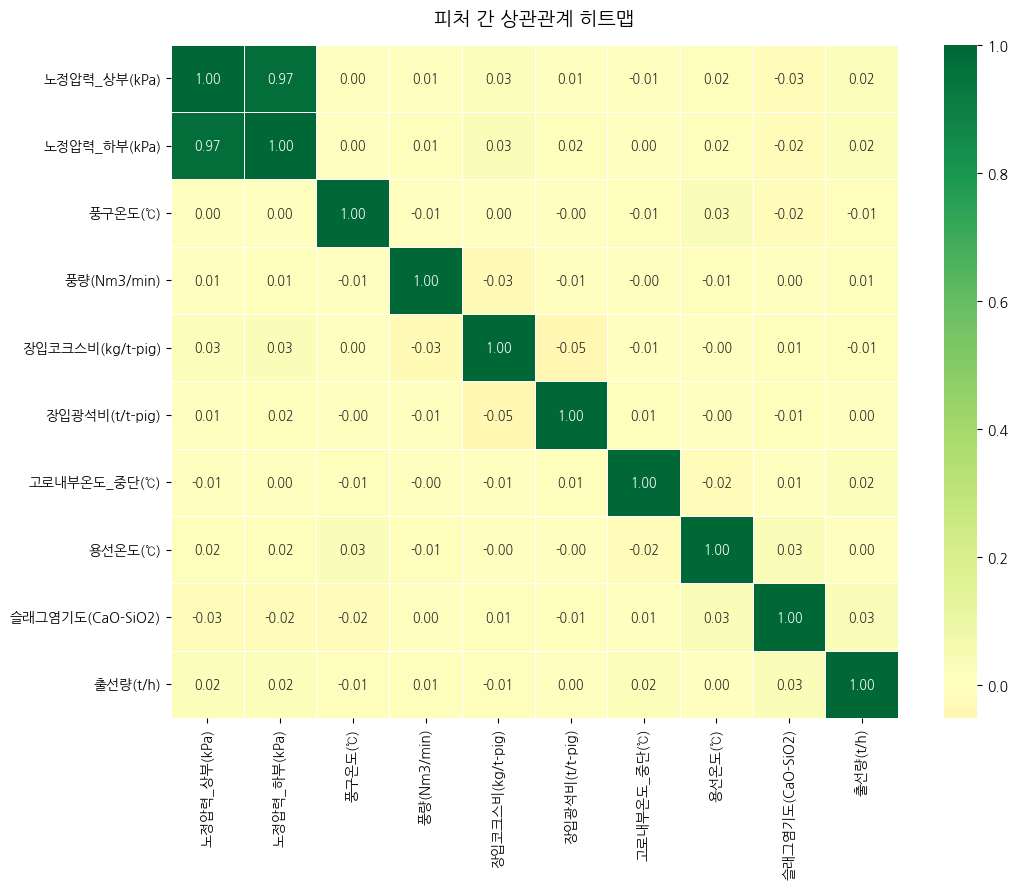

In [ ]:


corr_cols = ['노정압력_상부(kPa)', '노정압력_하부(kPa)', '풍구온도(℃)',
       '풍량(Nm3/min)', '장입코크스비(kg/t-pig)', '장입광석비(t/t-pig)', '고로내부온도_중단(℃)',
       '용선온도(℃)', '슬래그염기도(CaO-SiO2)', '출선량(t/h)']

# .corr() : 컬럼들 간의 피어슨 상관계수 행렬 계산
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
# sns.heatmap : 상관행렬을 색깔로 표현
#   annot=True  : 셀 안에 숫자 표시
#   fmt='.2f'   : 소수점 2자리
#   cmap='RdYlGn' : Red(음수) - Yellow(0) - Green(양수) 색상
#   center=0    : 0을 기준으로 색상 중앙 설정
#   linewidths  : 셀 사이 구분선 두께
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('피처 간 상관관계 히트맵', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

['측정일시', 'Heat_No', '고로번호', '노정압력_상부(kPa)', '노정압력_하부(kPa)', '풍구온도(℃)', '풍량(Nm3/min)', '장입코크스비(kg/t-pig)', '장입광석비(t/t-pig)', '고로내부온도_중단(℃)', '용선온도(℃)', '슬래그염기도(CaO-SiO2)', '출선량(t/h)', 'Si 실측(%)', 'S 실측(%)']


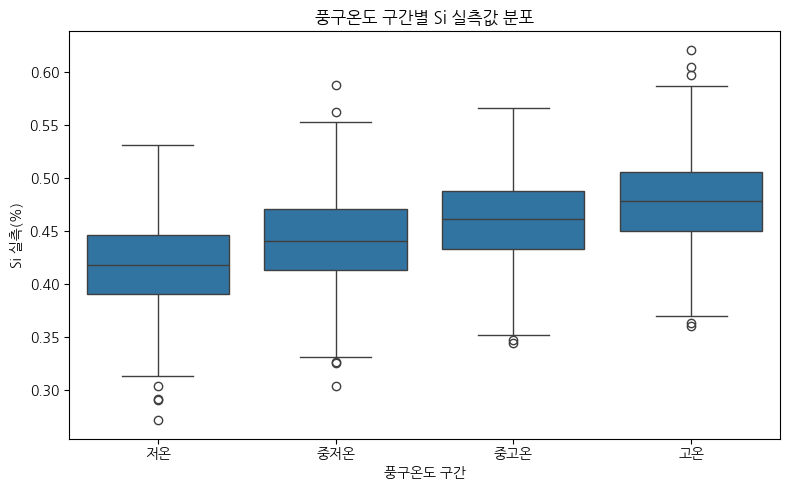

         count      mean       std
풍구온도_구간                           
저온         744  0.418554  0.041687
중저온        714  0.441784  0.042028
중고온        702  0.460970  0.040510
고온         720  0.477875  0.041059


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(df.columns.tolist())

# 풍구온도를 4개 구간으로 나누기 (사분위 기준)
df_box1 = df.copy()

df_box1['풍구온도_구간'] = pd.qcut(
    df_box1['풍구온도(℃)'],
    q=4,
    labels=['저온', '중저온', '중고온', '고온']
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_box1,
    x='풍구온도_구간',
    y='Si 실측(%)'
)

plt.title('풍구온도 구간별 Si 실측값 분포')
plt.xlabel('풍구온도 구간')
plt.ylabel('Si 실측(%)')
plt.tight_layout()
plt.show()

# 구간별 평균도 같이 확인
print(df_box1.groupby('풍구온도_구간')['Si 실측(%)'].agg(['count', 'mean', 'std']))

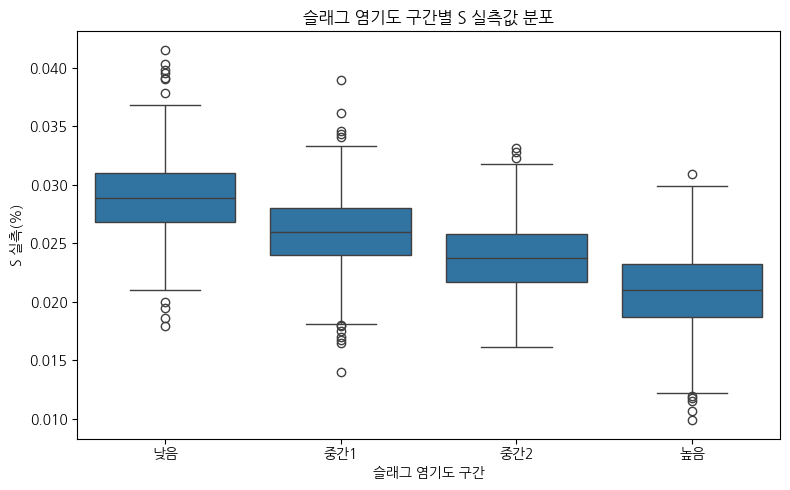

           count      mean       std
슬래그염기도_구간                           
낮음           726  0.028908  0.003410
중간1          722  0.025955  0.003198
중간2          714  0.023748  0.003029
높음           718  0.020934  0.003344


In [ ]:
df_box2 = df.copy()

df_box2['슬래그염기도_구간'] = pd.qcut(
    df_box2['슬래그염기도(CaO-SiO2)'],
    q=4,
    labels=['낮음', '중간1', '중간2', '높음']
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_box2,
    x='슬래그염기도_구간',
    y='S 실측(%)'
)

plt.title('슬래그 염기도 구간별 S 실측값 분포')
plt.xlabel('슬래그 염기도 구간')
plt.ylabel('S 실측(%)')
plt.tight_layout()
plt.show()

print(df_box2.groupby('슬래그염기도_구간')['S 실측(%)'].agg(['count', 'mean', 'std']))

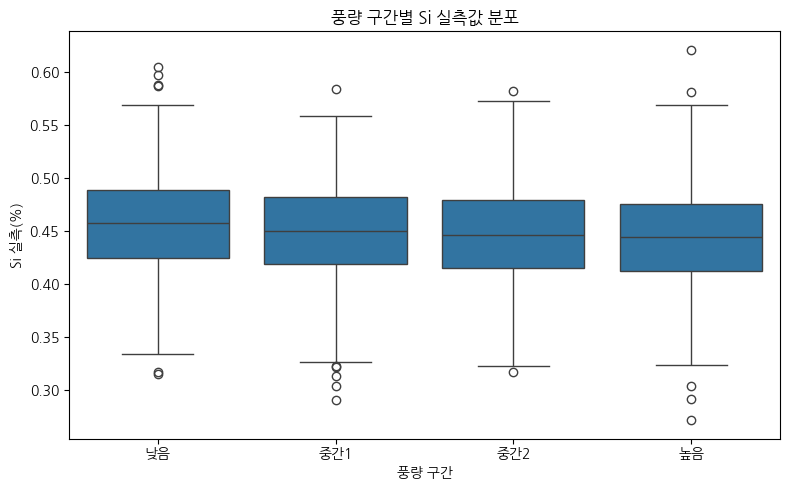

       count      mean       std
풍량_구간                           
낮음       721  0.456459  0.047577
중간1      719  0.449325  0.046047
중간2      722  0.446982  0.045712
높음       718  0.445148  0.047655


In [ ]:
df_box3 = df.copy()

df_box3['풍량_구간'] = pd.qcut(
    df_box3['풍량(Nm3/min)'],
    q=4,
    labels=['낮음', '중간1', '중간2', '높음']
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_box3,
    x='풍량_구간',
    y='Si 실측(%)'
)

plt.title('풍량 구간별 Si 실측값 분포')
plt.xlabel('풍량 구간')
plt.ylabel('Si 실측(%)')
plt.tight_layout()
plt.show()

print(df_box3.groupby('풍량_구간')['Si 실측(%)'].agg(['count', 'mean', 'std']))

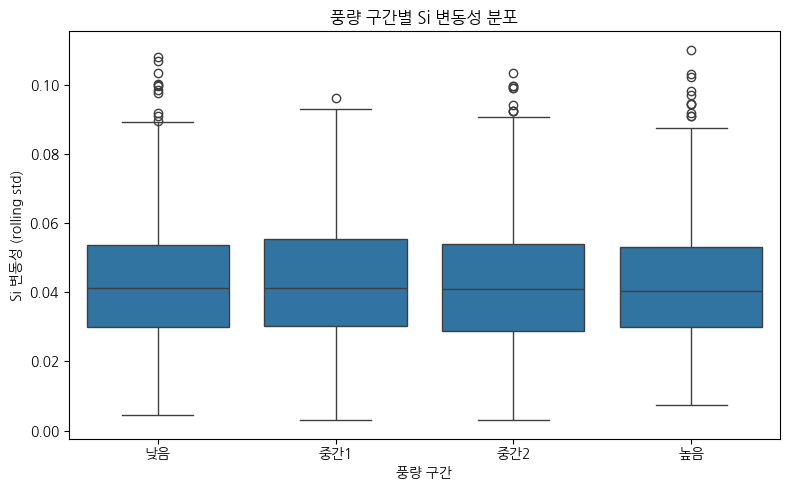

       count      mean       std
풍량_구간                           
낮음       721  0.043234  0.017926
중간1      719  0.043517  0.017770
중간2      722  0.042712  0.018226
높음       715  0.042673  0.017857


In [ ]:
df_vol = df.copy()

# 시간순 정렬
df_vol = df_vol.sort_values('측정일시').reset_index(drop=True)

# Si 변동성 생성 (4개 시점 rolling std)
df_vol['Si_변동성'] = df_vol['Si 실측(%)'].rolling(window=4).std()

# 결측 제거
df_vol = df_vol.dropna(subset=['Si_변동성']).copy()

# 풍량 구간화
df_vol['풍량_구간'] = pd.qcut(
    df_vol['풍량(Nm3/min)'],
    q=4,
    labels=['낮음', '중간1', '중간2', '높음']
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_vol,
    x='풍량_구간',
    y='Si_변동성'
)

plt.title('풍량 구간별 Si 변동성 분포')
plt.xlabel('풍량 구간')
plt.ylabel('Si 변동성 (rolling std)')
plt.tight_layout()
plt.show()

print(df_vol.groupby('풍량_구간')['Si_변동성'].agg(['count', 'mean', 'std']))

          Si 실측(%)  S 실측(%)
Si 실측(%)   1.00000  0.02041
S 실측(%)    0.02041  1.00000


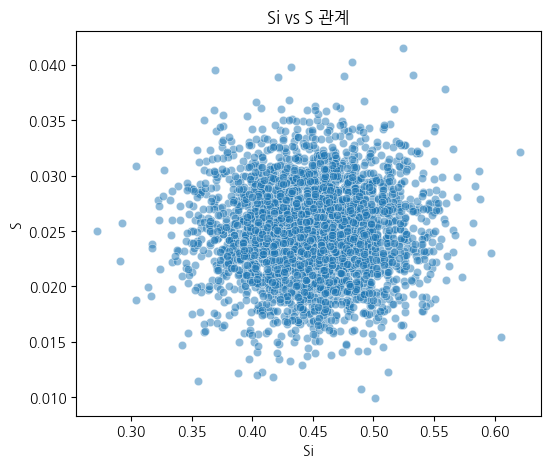

In [ ]:
print(df[['Si 실측(%)', 'S 실측(%)']].corr())

plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df,
    x='Si 실측(%)',
    y='S 실측(%)',
    alpha=0.5
)

plt.title('Si vs S 관계')
plt.xlabel('Si')
plt.ylabel('S')

plt.show()

                    count      mean       std
풍구온도_2그룹 슬래그염기도_구간                           
고온군      낮음           376  0.028851  0.003424
         중간1          356  0.025963  0.003297
         중간2          347  0.023838  0.003053
         높음           343  0.020952  0.003236
저온군      낮음           350  0.028969  0.003398
         중간1          366  0.025948  0.003104
         중간2          367  0.023663  0.003007
         높음           375  0.020917  0.003443


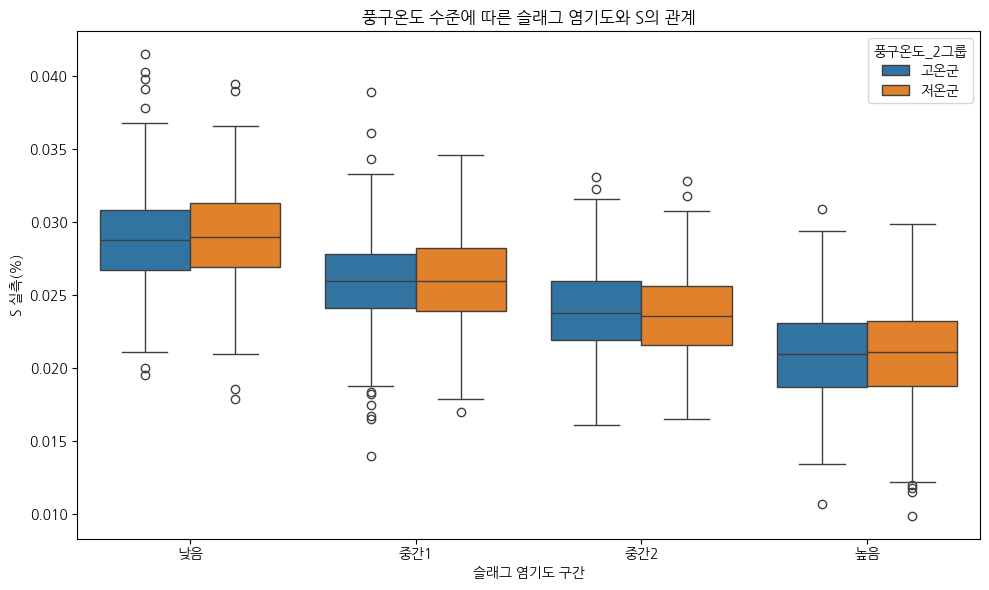

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 복사본
df_h5 = df.copy()

# 1) 풍구온도를 2개 그룹으로 나누기 (중앙값 기준)
temp_median = df_h5['풍구온도(℃)'].median()

df_h5['풍구온도_2그룹'] = df_h5['풍구온도(℃)'].apply(
    lambda x: '저온군' if x <= temp_median else '고온군'
)

# 2) 슬래그 염기도를 4개 구간으로 나누기
df_h5['슬래그염기도_구간'] = pd.qcut(
    df_h5['슬래그염기도(CaO-SiO2)'],
    q=4,
    labels=['낮음', '중간1', '중간2', '높음'],
    duplicates='drop'
)

# 3) 그룹별 평균 확인
result_table = df_h5.groupby(['풍구온도_2그룹', '슬래그염기도_구간'])['S 실측(%)'].agg(['count', 'mean', 'std'])
print(result_table)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_h5,
    x='슬래그염기도_구간',
    y='S 실측(%)',
    hue='풍구온도_2그룹'
)

plt.title('풍구온도 수준에 따른 슬래그 염기도와 S의 관계')
plt.xlabel('슬래그 염기도 구간')
plt.ylabel('S 실측(%)')
plt.tight_layout()
plt.show()

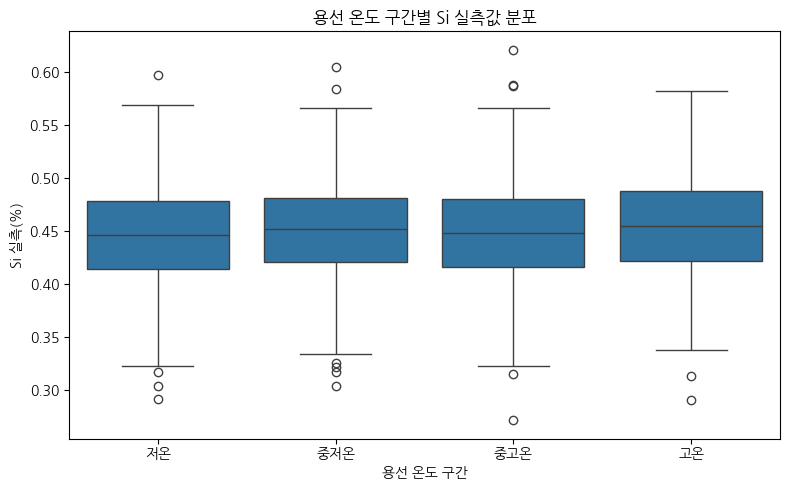

         count      mean       std
용선온도_구간                           
저온         775  0.446760  0.047144
중저온        723  0.449943  0.046689
중고온        682  0.447336  0.047116
고온         700  0.454111  0.046482


In [ ]:
df_h_new = df.copy()

# 용선 온도 4구간
df_h_new['용선온도_구간'] = pd.qcut(
    df_h_new['용선온도(℃)'],
    q=4,
    labels=['저온', '중저온', '중고온', '고온'],
    duplicates='drop'
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_h_new,
    x='용선온도_구간',
    y='Si 실측(%)'
)

plt.title('용선 온도 구간별 Si 실측값 분포')
plt.xlabel('용선 온도 구간')
plt.ylabel('Si 실측(%)')
plt.tight_layout()
plt.show()

print(df_h_new.groupby('용선온도_구간')['Si 실측(%)'].agg(['count', 'mean', 'std']))

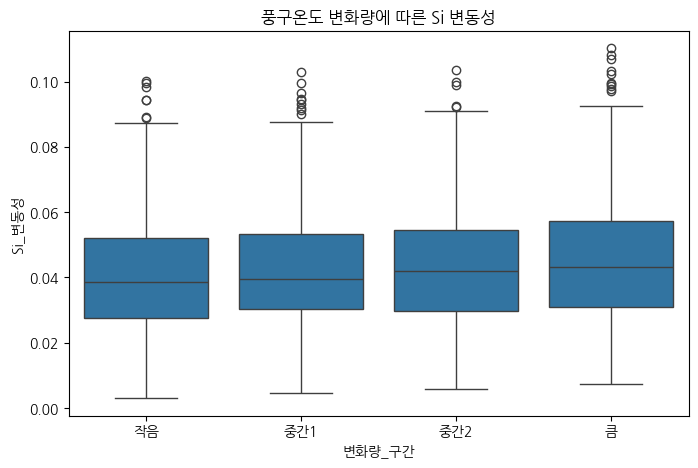

,Si_변동성
변화량_구간,
작음,0.041244
중간1,0.042343
중간2,0.043329
큼,0.045334


In [ ]:
df_var = df.copy().sort_values('측정일시').reset_index(drop=True)

# 풍구온도 변화량 (절대값)
df_var['풍구온도_변화량'] = df_var['풍구온도(℃)'].diff().abs()

df_var['Si_변동성'] = df_var['Si 실측(%)'].rolling(window=4).std()

df_var = df_var.dropna(subset=['풍구온도_변화량', 'Si_변동성'])

df_var['변화량_구간'] = pd.qcut(
    df_var['풍구온도_변화량'],
    q=4,
    labels=['작음', '중간1', '중간2', '큼']
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_var,
    x='변화량_구간',
    y='Si_변동성'
)

plt.title('풍구온도 변화량에 따른 Si 변동성')
plt.show()

df_var.groupby('변화량_구간')['Si_변동성'].mean()